<a href="https://colab.research.google.com/github/JorgePeje/test-python-utec/blob/main/cantidabks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [1]:
from google.colab import files
uploaded = files.upload()

Saving cantidadbks2024-2026.xlsx to cantidadbks2024-2026.xlsx


In [3]:
# Cargar y preparar data

import pandas as pd

# Reemplaza con el nombre exacto de tu archivo
df = pd.read_excel("cantidadbks2024-2026.xlsx")

# Limpiar nombres de columnas
df.columns = df.columns.str.strip()

# Convertir fecha
df['Fec. Aprobado por Controlador técnico'] = pd.to_datetime(
    df['Fec. Aprobado por Controlador técnico'], dayfirst=True
)

# Crear columnas de análisis
df['Año'] = df['Fec. Aprobado por Controlador técnico'].dt.year
df['Mes'] = df['Fec. Aprobado por Controlador técnico'].dt.month

In [4]:
# 🔹 3. Agrupar data (BKs por mes, guardia y año)


df_group = df.groupby(['Guardia', 'Año', 'Mes']).size().reset_index(name='Cantidad_BK')

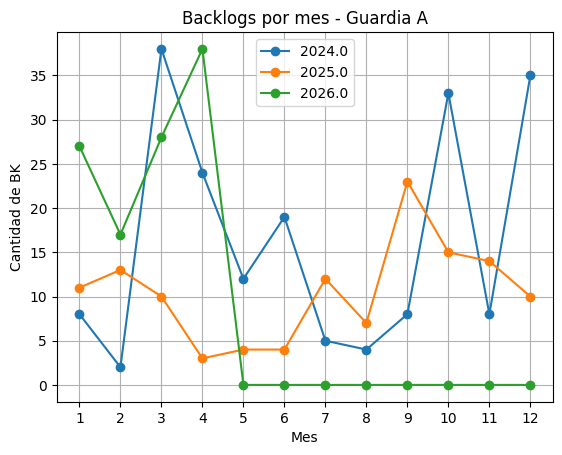

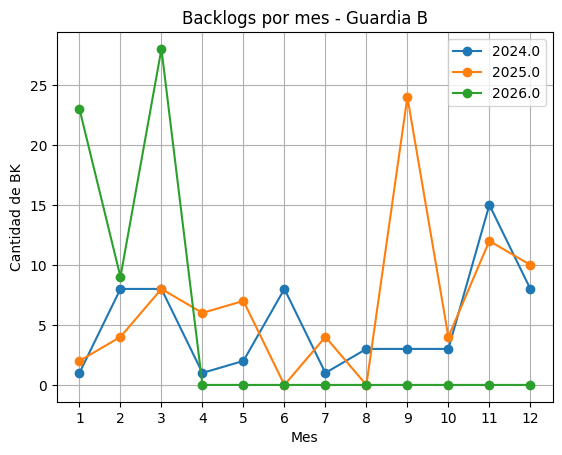

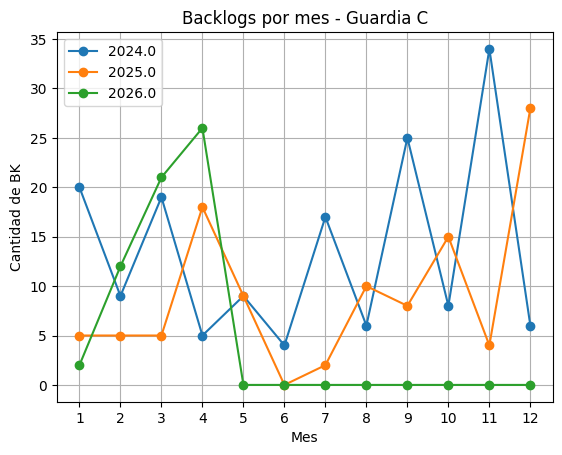

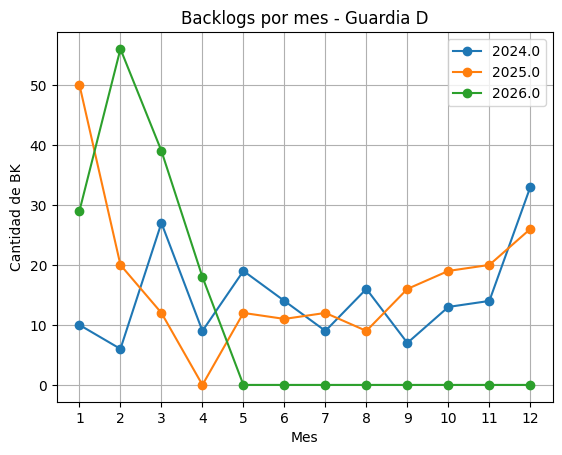

In [5]:
# 🔹 4. Graficar (una gráfica por guardia, líneas por año)


import matplotlib.pyplot as plt

# Lista de guardias
guardias = df_group['Guardia'].unique()

for guardia in guardias:
    plt.figure()

    data_guardia = df_group[df_group['Guardia'] == guardia]

    for año in sorted(data_guardia['Año'].unique()):
        data_año = data_guardia[data_guardia['Año'] == año]

        # Asegurar que estén los 12 meses
        meses = pd.DataFrame({'Mes': range(1,13)})
        data_año = meses.merge(data_año, on='Mes', how='left').fillna(0)

        plt.plot(data_año['Mes'], data_año['Cantidad_BK'], marker='o', label=str(año))

    plt.title(f'Backlogs por mes - Guardia {guardia}')
    plt.xlabel('Mes')
    plt.ylabel('Cantidad de BK')
    plt.xticks(range(1,13))
    plt.legend()
    plt.grid()

    plt.show()